# EDA Amazon Customer Behavior – Data Understanding y Univariante

En este cuaderno realizo:

1. **Data understanding**: estructura del dataset, diccionario de datos y tipos.
2. **Data cleaning**: corrección de tipos (fechas, numéricos, categóricas).
3. **Feature engineering**: flags de categorías, variables ordinales, edad y outliers.
4. **Análisis univariante**: distribución, centralidad y dispersión de variables clave.

In [82]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

### 1. Carga de datos y vista inicial

Cargo el archivo CSV con las respuestas de la encuesta de clientes.
En este paso solo reviso:

- Dimensiones del dataset.
- Primeras filas para entender el contenido de cada columna.

In [43]:
df = pd.read_csv("../data/Amazon Customer Behavior Survey.csv")

display(df.head())

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas
0,2023/06/04 1:28:19 PM GMT+5:30,23,Female,Few times a month,Beauty and Personal Care,Yes,Few times a week,Keyword,Multiple pages,1,...,Sometimes,Yes,Occasionally,Yes,2,Yes,1,1,Competitive prices,Reducing packaging waste
1,2023/06/04 2:30:44 PM GMT+5:30,23,Female,Once a month,Clothing and Fashion,Yes,Few times a month,Keyword,Multiple pages,1,...,Rarely,No,Heavily,Yes,2,Sometimes,3,2,Wide product selection,Reducing packaging waste
2,2023/06/04 5:04:56 PM GMT+5:30,24,Prefer not to say,Few times a month,Groceries and Gourmet Food;Clothing and Fashion,No,Few times a month,Keyword,Multiple pages,2,...,Rarely,No,Occasionally,No,4,No,3,3,Competitive prices,Product quality and accuracy
3,2023/06/04 5:13:00 PM GMT+5:30,24,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,5,...,Sometimes,Yes,Heavily,Yes,3,Sometimes,3,4,Competitive prices,Product quality and accuracy
4,2023/06/04 5:28:06 PM GMT+5:30,22,Female,Less than once a month,Beauty and Personal Care;Clothing and Fashion,Yes,Few times a month,Filter,Multiple pages,1,...,Rarely,No,Heavily,Yes,4,Yes,2,2,Competitive prices,Product quality and accuracy


### 2. Data understanding – Diccionario de datos básico

Antes de limpiar, documento las variables disponibles mediante un
diccionario de datos automático con:

- `columna`: nombre de la variable.
- `dtype`: tipo detectado inicialmente por pandas.
- `% nulos`: porcentaje de valores faltantes.
- `unicos`: número de valores distintos.
- `ejemplo`: un valor de ejemplo distinto de nulo.

Este diccionario sirve de base para documentar cada variable, su tipo
(continua/categórica) y qué puede aportar al análisis.

In [44]:
data_dict = pd.DataFrame({
    "columna": df.columns,
    "dtype": df.dtypes.values,
    "nulos_pct": (df.isnull().mean() * 100).round(1).values,
    "unicos": df.nunique().values,
    "ejemplo": [
        df[c].dropna().iloc[0] if len(df[c].dropna()) > 0 else None
        for c in df.columns
    ],
})

display(data_dict)

# Guardar como CSV para documentación externa (hoja de cálculo)
data_dict.to_csv("../data/data_dictionary.csv", index=False)

,columna,dtype,nulos_pct,unicos,ejemplo
0,Timestamp,str,0.0,601,2023/06/04 1:28:19 PM GMT+5:30
1,age,int64,0.0,50,23
2,Gender,str,0.0,4,Female
3,Purchase_Frequency,str,0.0,5,Few times a month
4,Purchase_Categories,str,0.0,29,Beauty and Personal Care
5,Personalized_Recommendation_Frequency,str,0.0,3,Yes
6,Browsing_Frequency,str,0.0,4,Few times a week
7,Product_Search_Method,str,0.3,4,Keyword
8,Search_Result_Exploration,str,0.0,2,Multiple pages
9,Customer_Reviews_Importance,int64,0.0,5,1


In [51]:
df = df.dropna()

### 3. Data cleaning – Corrección de tipos y nombres de columnas

Un número cargado como texto o una fecha como `object` pueden generar
errores silenciosos en el análisis posterior. Por eso corrijo los tipos:

- Convierto la marca temporal a `datetime`.
- Convierto `age` y las variables de importancia/satisfacción a numérico.
- Convierto algunas variables a tipo categórico para ganar legibilidad
  y ahorrar memoria.
- Estandarizo nombres de columnas (minúsculas, sin espacios).

In [53]:
# 3.1 Renombrar columnas a un formato consistente
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace(r"[^\w]", "", regex=True)
)

print("Columnas después de renombrar:")
print(df.columns.tolist())

# 3.2 Resolver columnas duplicadas de personalized recommendation

# Detectar nombres duplicados
cols = pd.Series(df.columns)
dups = cols[cols.duplicated()].unique()
print("\nColumnas duplicadas:", dups)

# Si 'personalized_recommendation_frequency' está duplicada,
# renombramos la segunda ocurrencia para distinguirla
if "personalized_recommendation_frequency" in dups:
    mask = cols == "personalized_recommendation_frequency"
    idx_duplicados = np.where(mask)[0]
    if len(idx_duplicados) > 1:
        seg_idx = idx_duplicados[1]
        new_name = "personalized_recommendation_frequency_num"
        df.columns = [
            new_name if i == seg_idx else col
            for i, col in enumerate(df.columns)
        ]

print("\nColumnas después de resolver duplicados:")
print(df.columns.tolist())

# 3.3 Conversión de fecha (timestamp)
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

# 3.4 Conversión de numéricos
numeric_candidates = [
    "age",
    "customer_reviews_importance",
    "rating_accuracy",
    "shopping_satisfaction",
]

numeric_candidates = [c for c in numeric_candidates if c in df.columns]

print("\nColumnas numéricas a convertir:", numeric_candidates)

for col in numeric_candidates:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3.5 Conversión a categórico de algunas variables de texto
cat_candidates = [
    "gender",
    "purchase_frequency",
    "purchase_categories",
    "personalized_recommendation_frequency",
    "browsing_frequency",
    "product_search_method",
    "search_result_exploration",
    "add_to_cart_browsing",
    "cart_completion_frequency",
    "cart_abandonment_factors",
    "saveforlater_frequency",
    "review_left",
    "review_reliability",
    "review_helpfulness",
    "recommendation_helpfulness",
    "service_appreciation",
    "improvement_areas",
]

cat_candidates = [c for c in cat_candidates if c in df.columns]

for col in cat_candidates:
    df[col] = df[col].astype("category")

# 3.6 Eliminar filas con timestamp o age inválidos
df = df.dropna(subset=["timestamp", "age"]).copy()
df["age"] = df["age"].astype(int)

print("\nTipos después de la conversión:")
print(df.dtypes)

Columnas después de renombrar:
['timestamp', 'age', 'gender', 'purchase_frequency', 'purchase_categories', 'personalized_recommendation_frequency', 'browsing_frequency', 'product_search_method', 'search_result_exploration', 'customer_reviews_importance', 'add_to_cart_browsing', 'cart_completion_frequency', 'cart_abandonment_factors', 'saveforlater_frequency', 'review_left', 'review_reliability', 'review_helpfulness', 'personalized_recommendation_frequency', 'recommendation_helpfulness', 'rating_accuracy', 'shopping_satisfaction', 'service_appreciation', 'improvement_areas']

Columnas duplicadas: <StringArray>
['personalized_recommendation_frequency']
Length: 1, dtype: str

Columnas después de resolver duplicados:
['timestamp', 'age', 'gender', 'purchase_frequency', 'purchase_categories', 'personalized_recommendation_frequency', 'browsing_frequency', 'product_search_method', 'search_result_exploration', 'customer_reviews_importance', 'add_to_cart_browsing', 'cart_completion_frequency', 

C:\Users\anaco\AppData\Local\Temp\ipykernel_5820\4123464060.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(


### 4. Calidad de datos y estructura final

Reviso de forma compacta:

- Porcentaje de nulos por columna.
- Número de filas duplicadas.

Esto confirma que el dataset está en un estado razonable para
continuar con el EDA.

In [54]:
print("\nValores nulos (%):")
print((df.isnull().mean() * 100).round(1))

print("\nNúmero de filas duplicadas:")
print(df.duplicated().sum())


Valores nulos (%):
timestamp                                    0.0
age                                          0.0
gender                                       0.0
purchase_frequency                           0.0
purchase_categories                          0.0
personalized_recommendation_frequency        0.0
browsing_frequency                           0.0
product_search_method                        0.0
search_result_exploration                    0.0
customer_reviews_importance                  0.0
add_to_cart_browsing                         0.0
cart_completion_frequency                    0.0
cart_abandonment_factors                     0.0
saveforlater_frequency                       0.0
review_left                                  0.0
review_reliability                           0.0
review_helpfulness                           0.0
personalized_recommendation_frequency_num    0.0
recommendation_helpfulness                   0.0
rating_accuracy                              0.0


### 5. Separación de variables numéricas y categóricas

Separo las columnas numéricas de las categóricas para organizar
mejor el análisis univariante posterior:

- Numéricas: edad, importancia de reseñas, rating, satisfacción, etc.
- Categóricas: género, frecuencia de compra, categorías de compra, etc.

In [55]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["category", "object"]).columns.tolist()

print("\nVariables numéricas:", num_cols)
print("\nVariables categóricas:", cat_cols)


Variables numéricas: ['age', 'customer_reviews_importance', 'personalized_recommendation_frequency_num', 'rating_accuracy', 'shopping_satisfaction']

Variables categóricas: ['gender', 'purchase_frequency', 'purchase_categories', 'personalized_recommendation_frequency', 'browsing_frequency', 'product_search_method', 'search_result_exploration', 'add_to_cart_browsing', 'cart_completion_frequency', 'cart_abandonment_factors', 'saveforlater_frequency', 'review_left', 'review_reliability', 'review_helpfulness', 'recommendation_helpfulness', 'service_appreciation', 'improvement_areas']



#### variables

1. **age** = Edad del encuestado.

2. **gender** = Género del encuestado.

3. **purchase_frequency** = ¿Con qué frecuencia realizas compras en Amazon?

4. **purchase_categories** = ¿Qué categorías de productos sueles comprar en Amazon?

5. **personalized_recommendation_frequency** = ¿Alguna vez has comprado un producto basándote en recomendaciones personalizadas de Amazon?

6. **browsing_frequency** = ¿Con qué frecuencia navegas por el sitio web o la aplicación de Amazon?

7. **product_search_method** = ¿Cómo buscas productos en Amazon?

8. **search_result_exploration** = ¿Sueles explorar varias páginas de resultados de búsqueda o te quedas en la primera página?

9. **customer_reviews_importance** = ¿Qué importancia tienen las reseñas de clientes en tu proceso de toma de decisiones?

10. **add_to_cart_browsing** = ¿Añades productos a tu carrito mientras navegas por Amazon?

11. **cart_completion_frequency** = ¿Con qué frecuencia completas la compra después de añadir productos al carrito?

12. **cart_abandonment_factors** = ¿Qué factores influyen en tu decisión de abandonar una compra en el carrito?

13. **saveforlater_frequency** = ¿Utilizas la función “Guardar para más tarde” de Amazon y, si es así, con qué frecuencia?

14. **review_left** = ¿Alguna vez has dejado una reseña de un producto en Amazon?

15. **review_reliability** = ¿Cuánto confías en las reseñas de productos al realizar una compra?

16. **review_helpfulness** = ¿Encuentras información útil en las reseñas de otros clientes?

17. **personalized_recommendation_frequency** (numérica / frecuencia) = ¿Con qué frecuencia recibes recomendaciones personalizadas de productos de Amazon?

18. **recommendation_helpfulness** = ¿Te resultan útiles las recomendaciones?

19. **rating_accuracy** = ¿Cómo calificarías la relevancia y precisión de las recomendaciones que recibes?

20. **shopping_satisfaction** = ¿Qué tan satisfecho estás con tu experiencia general de compra en Amazon?

21. **service_appreciation** = ¿Qué aspectos de los servicios de Amazon aprecias más?

22. **improvement_areas** = ¿Hay áreas en las que crees que Amazon puede mejorar?

### 6. Copia para EDA y feature engineering

Creo una copia (`df_eda`) sobre la que añado variables derivadas:

- Flags de categorías de compra.
- Variables ordinales (incluyendo `personalized_recommendation_frequency_ord`).
- Variables asociadas a outliers de edad (≥ 60 años).

In [56]:
df_eda = df.copy()

### 7. Feature engineering – Flags de categorías de compra

La variable `purchase_categories` puede contener varias categorías
separadas por `;`. Para facilitar análisis posteriores, creo variables
binarias para las categorías principales.

In [57]:
df_eda["purchase_categories_str"] = df_eda["purchase_categories"].astype(str)

df_eda["buys_beauty"] = df_eda["purchase_categories_str"].str.contains(
    "Beauty and Personal Care", case=False, na=False
)

df_eda["buys_fashion"] = df_eda["purchase_categories_str"].str.contains(
    "Clothing and Fashion", case=False, na=False
)

df_eda["buys_groceries"] = df_eda["purchase_categories_str"].str.contains(
    "Groceries and Gourmet Food", case=False, na=False
)

df_eda["buys_home"] = df_eda["purchase_categories_str"].str.contains(
    "Home and Kitchen", case=False, na=False
)

df_eda["buys_others"] = df_eda["purchase_categories_str"].str.contains(
    "others", case=False, na=False
)

### 8. Feature engineering – Variables ordinales

Muchas variables de la encuesta tienen un orden natural de frecuencia
o intensidad. Por eso creo versiones ordinales numéricas, manteniendo
también la versión original para interpretación directa.

In [58]:
# Frecuencia de compra
purchasefrequency_map = {
    "less than once a month": 0,
    "once a month": 1,
    "few times a month": 2,
    "once a week": 3,
    "multiple times a week": 4,
}

# Frecuencia de navegación
browsingfrequency_map = {
    "rarely": 0,
    "few times a month": 1,
    "few times a week": 2,
    "multiple times a day": 3,
}

# Frecuencia tipo never/rarely/sometimes/often/always
freq_simple_map = {
    "never": 0,
    "rarely": 1,
    "sometimes": 2,
    "often": 3,
    "always": 4,
}

# Intensidad de fiabilidad: never → heavily
reliability_intensity_map = {
    "never": 0,
    "rarely": 1,
    "occasionally": 2,
    "moderately": 3,
    "heavily": 4,
}

helpfulness_map = {
    "no": 0,
    "sometimes": 1,
    "yes": 2,
}

search_exploration_map = {
    "first page": 0,
    "multiple pages": 1,
}

personalized_freq_text_map = {
    "no": 0,
    "sometimes": 1,
    "yes": 2,
}

df_eda["purchase_frequency_ord"] = (
    df_eda["purchase_frequency"]
    .astype(str).str.lower()
    .map(purchasefrequency_map)
)

df_eda["browsing_frequency_ord"] = (
    df_eda["browsing_frequency"]
    .astype(str).str.lower()
    .map(browsingfrequency_map)
)

df_eda["cart_completion_frequency_ord"] = (
    df_eda["cart_completion_frequency"]
    .astype(str).str.lower()
    .map(freq_simple_map)
)

df_eda["saveforlater_frequency_ord"] = (
    df_eda["saveforlater_frequency"]
    .astype(str).str.lower()
    .map(freq_simple_map)
)

df_eda["review_reliability_ord"] = (
    df_eda["review_reliability"]
    .astype(str).str.lower()
    .map(reliability_intensity_map)
)

df_eda["review_helpfulness_ord"] = (
    df_eda["review_helpfulness"]
    .astype(str).str.lower()
    .map(helpfulness_map)
)

df_eda["recommendation_helpfulness_ord"] = (
    df_eda["recommendation_helpfulness"]
    .astype(str).str.lower()
    .map(helpfulness_map)
)

df_eda["search_result_exploration_ord"] = (
    df_eda["search_result_exploration"]
    .astype(str).str.lower()
    .map(search_exploration_map)
)

df_eda["personalized_recommendation_frequency_ord"] = (
    df_eda.loc[:, "personalized_recommendation_frequency"]  
    .astype(str)
    .str.lower()
    .map(personalized_freq_text_map)
)

In [59]:
# Limpieza de categorías raras en variables textuales

# Reemplazar "." por NaN
df_eda["service_appreciation"] = df_eda["service_appreciation"].replace(".", np.nan)
df_eda["improvement_areas"] = df_eda["improvement_areas"].replace(".", np.nan)

# Quedarnos con las categorías principales y agrupar el resto en "Other"
top_service = df_eda["service_appreciation"].value_counts(dropna=True).index[:4]
df_eda["service_appreciation_clean"] = np.where(
    df_eda["service_appreciation"].isin(top_service),
    df_eda["service_appreciation"],
    "Other"
)

top_improvement = df_eda["improvement_areas"].value_counts(dropna=True).index[:4]
df_eda["improvement_areas_clean"] = np.where(
    df_eda["improvement_areas"].isin(top_improvement),
    df_eda["improvement_areas"],
    "Other"
)

### 9. Funciones auxiliares para análisis univariante

Defino dos funciones reutilizables:

- una para variables numéricas, con estadísticos, histograma y boxplot;
- otra para variables categóricas, con tabla de frecuencias y gráfico de barras.

Esto permite ordenar el EDA y mantener un criterio homogéneo.

In [60]:
def numeric_univariate_report(df, col):
    print(f"\n=== {col} ===")
    
    stats = df[col].agg(["count", "mean", "median", "std", "min", "max"])
    mode_series = df[col].mode(dropna=True)
    moda = mode_series.iloc[0] if len(mode_series) > 0 else np.nan
    stats["mode"] = moda
    display(stats.to_frame(name="value"))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"Histograma de {col}")

    sns.boxplot(x=df[col], ax=axes[1], color="#55A868")
    axes[1].set_title(f"Boxplot de {col}")

    plt.tight_layout()
    plt.show()


def categorical_univariate_report(df, col, topn=None):
    print(f"\n=== {col} ===")
    freq = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(dropna=False, normalize=True) * 100
    summary = pd.DataFrame({
        "count": freq,
        "percent": pct.round(2)
    })
    display(summary)

    if topn is not None:
        freq = freq.head(topn)

    plt.figure(figsize=(8, 4))
    freq.plot(kind="bar", color="#4C72B0")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### 10. Análisis univariante – Variables numéricas

Antes de definir grupos de edad u otros outliers, analizo las variables
numéricas mediante medidas de centralidad y dispersión, además de
histogramas y boxplots.

Esto permite detectar posibles valores extremos y entender mejor
el comportamiento general de cada variable.


=== age ===


,value
count,600.000000
mean,30.780000
median,26.000000
std,10.180914
min,3.000000
max,67.000000
mode,23.000000


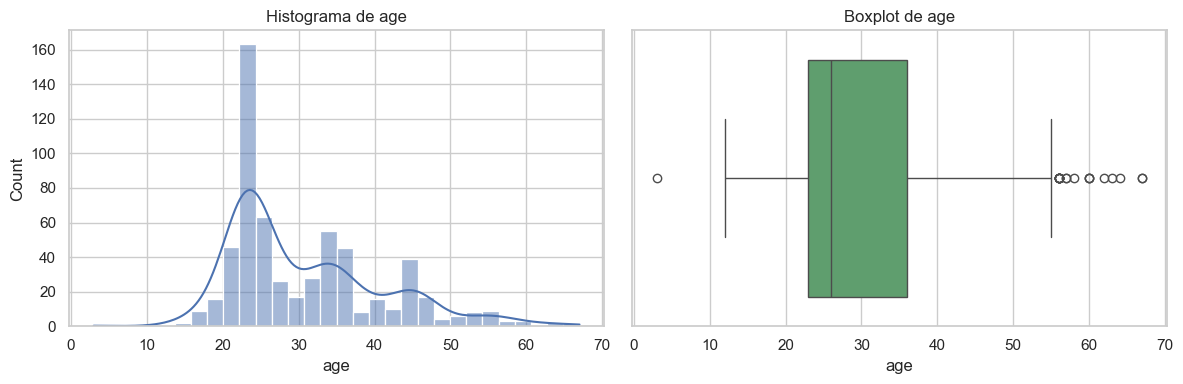


=== customer_reviews_importance ===


,value
count,600.000000
mean,2.481667
median,3.000000
std,1.185470
min,1.000000
max,5.000000
mode,3.000000


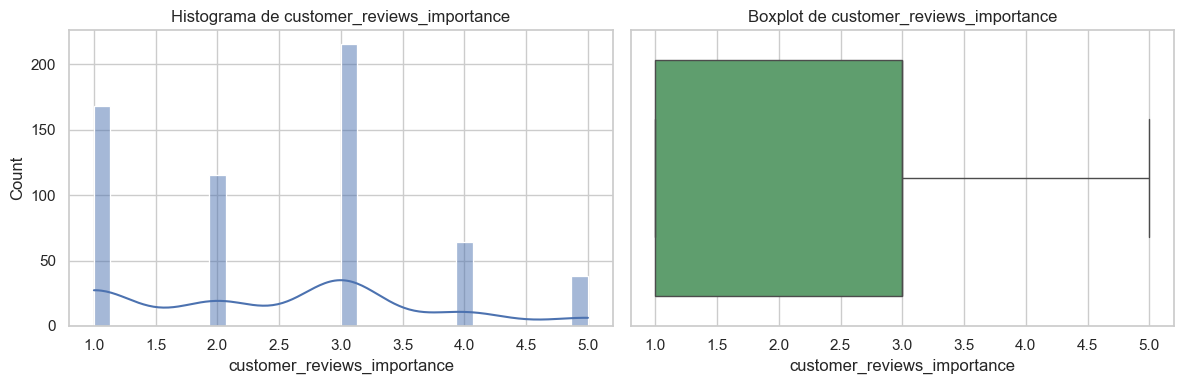


=== personalized_recommendation_frequency_ord ===


,value
count,600.000000
mean,0.786667
median,1.000000
std,0.758583
min,0.000000
max,2.000000
mode,0.000000


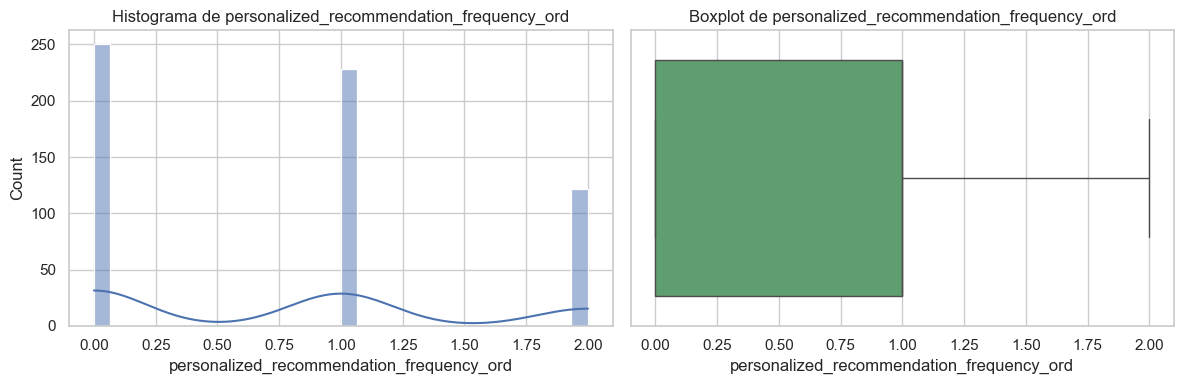


=== rating_accuracy ===


,value
count,600.000000
mean,2.671667
median,3.000000
std,0.901046
min,1.000000
max,5.000000
mode,3.000000


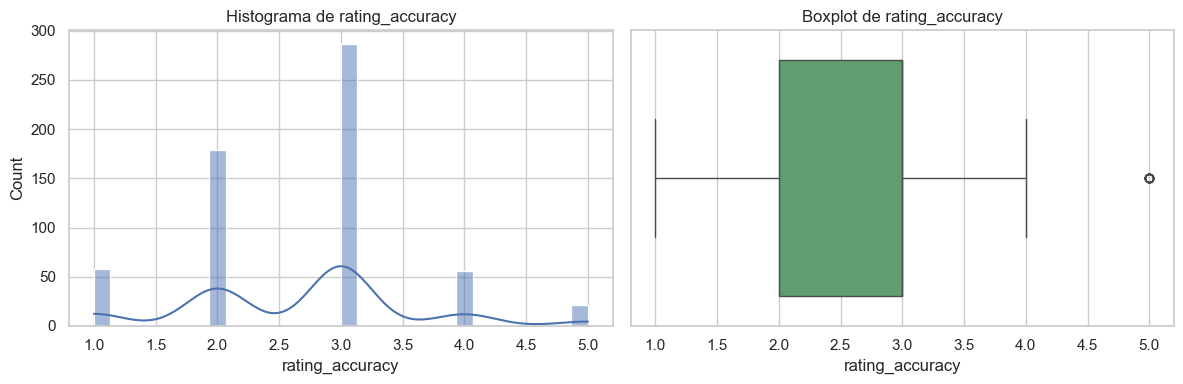


=== shopping_satisfaction ===


,value
count,600.000000
mean,2.463333
median,2.000000
std,1.013427
min,1.000000
max,5.000000
mode,3.000000


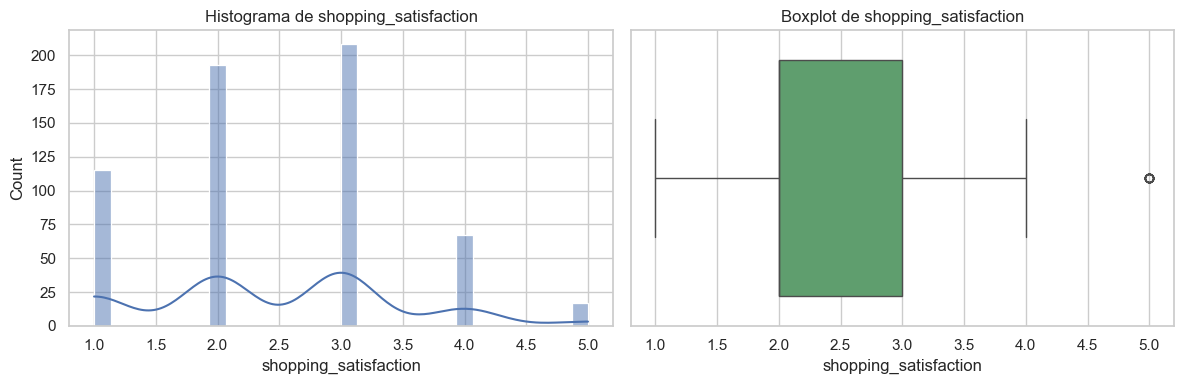

In [61]:
num_target_cols = [
    "age",
    "customer_reviews_importance",
    "personalized_recommendation_frequency_ord",
    "rating_accuracy",
    "shopping_satisfaction",
]

num_target_cols = [c for c in num_target_cols if c in df_eda.columns]

for col in num_target_cols:
    numeric_univariate_report(df_eda, col)

### 11. Revisión específica de outliers

Los outliers son hallazgos, no ruido. En este punto ilustro la detección
de outliers mediante el método IQR sobre una variable numérica y reviso
su representación con boxplot.

Outliers detectados en age: 20


,age
20,64
80,58
92,62
150,63
163,60


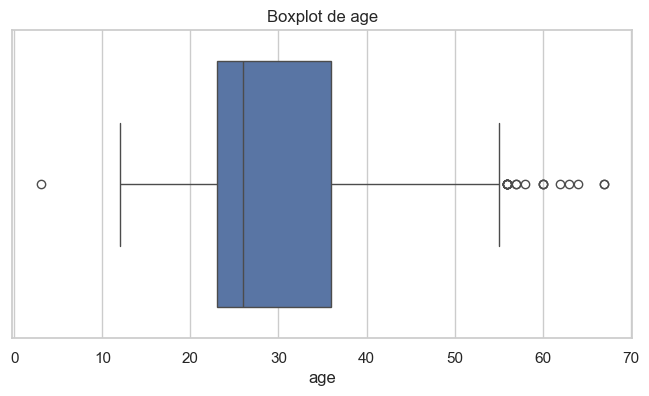

In [62]:
col_outlier = "age"

Q1 = df_eda[col_outlier].quantile(0.25)
Q3 = df_eda[col_outlier].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_eda[(df_eda[col_outlier] < lower) | (df_eda[col_outlier] > upper)]

print(f"Outliers detectados en {col_outlier}: {len(outliers)}")
display(outliers[[col_outlier]].head())

sns.boxplot(x=df_eda[col_outlier])
plt.title(f"Boxplot de {col_outlier}")
plt.show()

### 12. Edad y definición de grupo outlier

A partir del análisis univariante de `age`, creo variables auxiliares
para identificar observaciones de edad alta en la muestra.

En lugar de eliminarlas, las marco explícitamente para poder estudiarlas
después en el análisis bivariante.

In [63]:
df_eda["age_outlier_60"] = (df_eda["age"] >= 60).astype(int)
df_eda["edad_grupo"] = np.where(df_eda["age"] >= 60, "60_o_mas", "menos_60")

### 13. Análisis univariante – Variables categóricas

Para las variables categóricas reviso frecuencias absolutas y relativas,
además de gráficos de barras, con el objetivo de identificar categorías
dominantes y niveles con poca representación.


=== gender ===


,count,percent
gender,,
Female,350,58.33
Male,142,23.67
Prefer not to say,89,14.83
Others,19,3.17


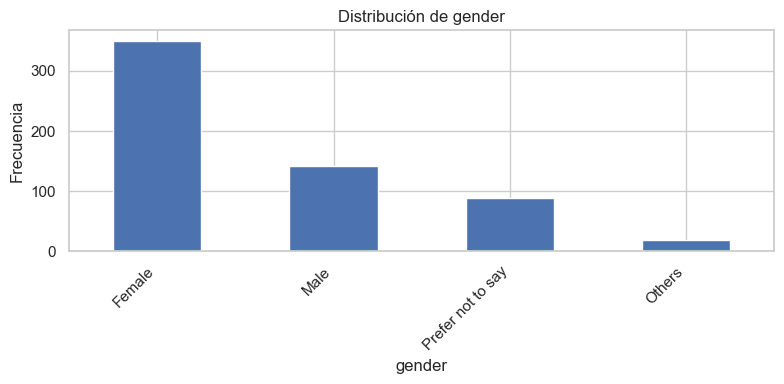


=== purchase_frequency ===


,count,percent
purchase_frequency,,
Few times a month,202,33.67
Less than once a month,124,20.67
Once a week,112,18.67
Once a month,106,17.67
Multiple times a week,56,9.33


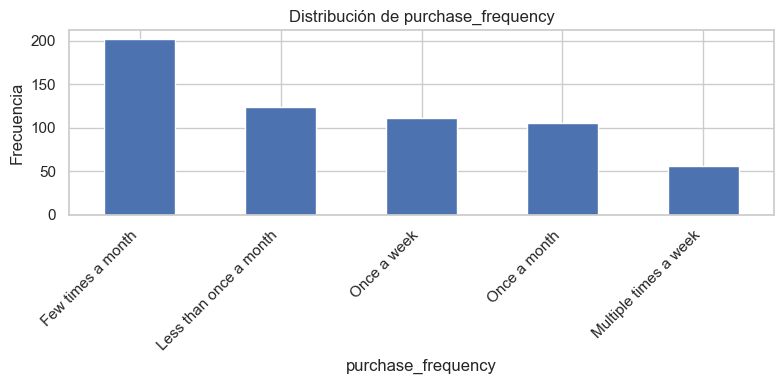


=== browsing_frequency ===


,count,percent
browsing_frequency,,
Few times a week,248,41.33
Few times a month,199,33.17
Rarely,77,12.83
Multiple times a day,76,12.67


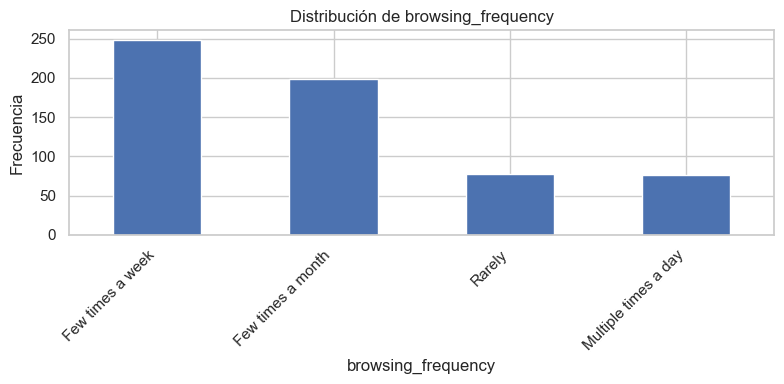


=== product_search_method ===


,count,percent
product_search_method,,
categories,223,37.17
Keyword,214,35.67
Filter,127,21.17
others,36,6.00


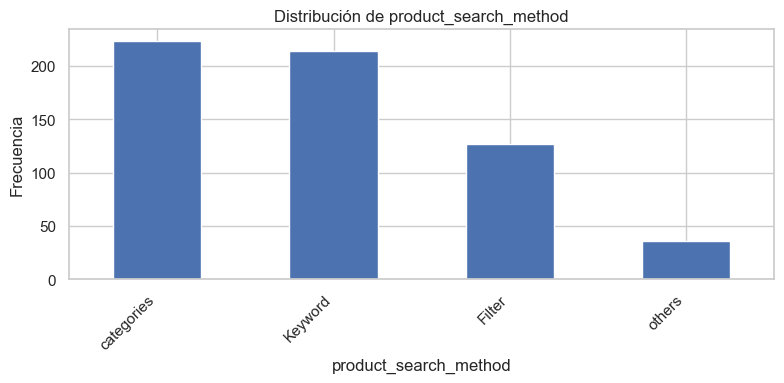


=== search_result_exploration ===


,count,percent
search_result_exploration,,
Multiple pages,440,73.33
First page,160,26.67


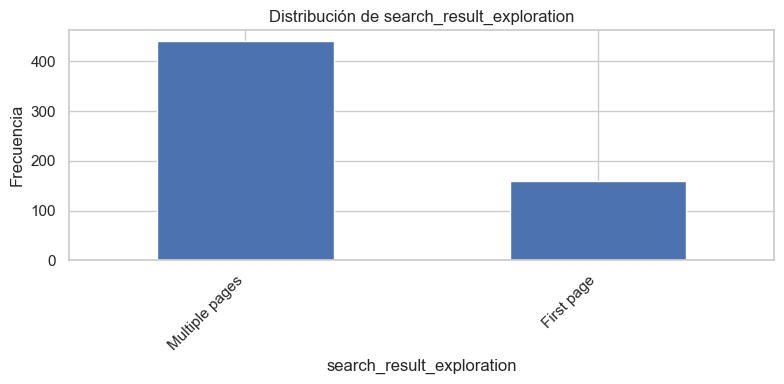


=== cart_completion_frequency ===


,count,percent
cart_completion_frequency,,
Sometimes,303,50.50
Often,158,26.33
Rarely,72,12.00
Always,46,7.67
Never,21,3.50


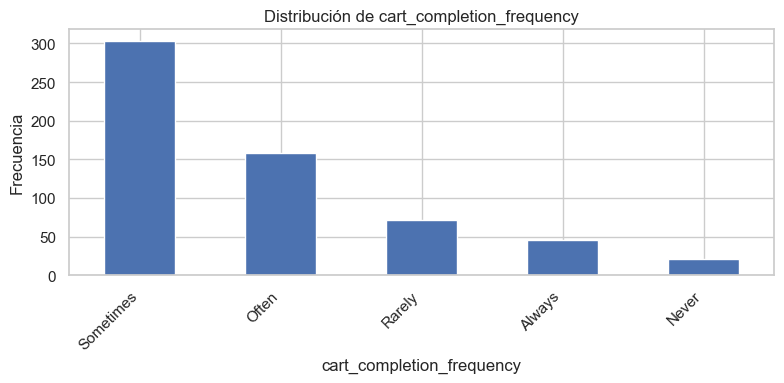


=== saveforlater_frequency ===


,count,percent
saveforlater_frequency,,
Sometimes,251,41.83
Often,154,25.67
Rarely,82,13.67
Never,59,9.83
Always,54,9.00


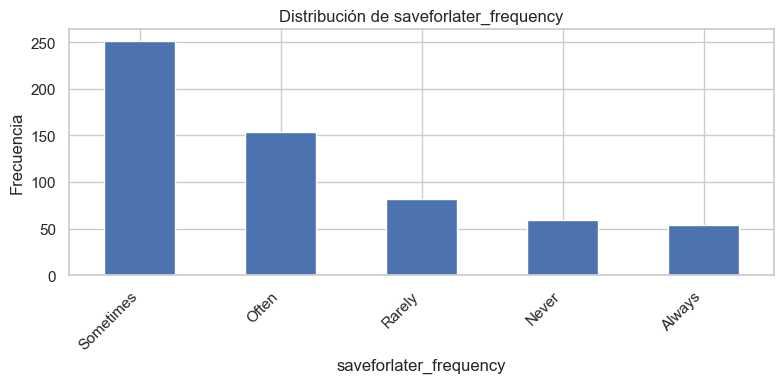


=== review_reliability ===


,count,percent
review_reliability,,
Moderately,197,32.83
Occasionally,190,31.67
Heavily,149,24.83
Rarely,41,6.83
Never,23,3.83


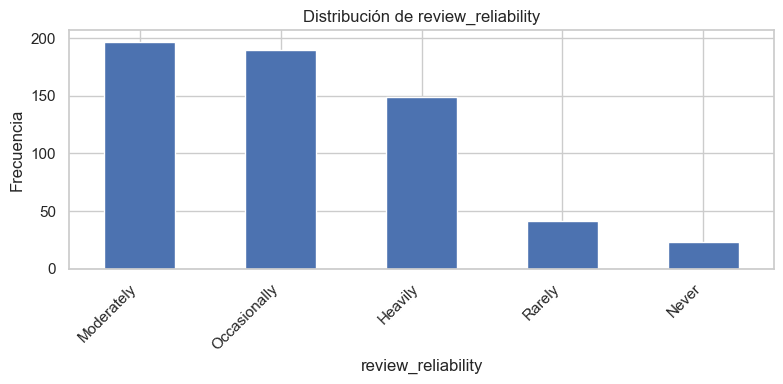


=== review_helpfulness ===


,count,percent
review_helpfulness,,
Yes,237,39.50
Sometimes,226,37.67
No,137,22.83


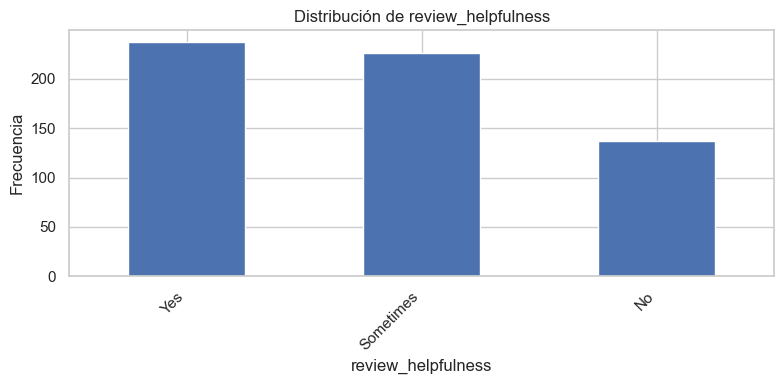


=== service_appreciation_clean ===


,count,percent
service_appreciation_clean,,
Product recommendations,185,30.83
Competitive prices,182,30.33
Wide product selection,149,24.83
User-friendly website/app interface,79,13.17
Other,5,0.83


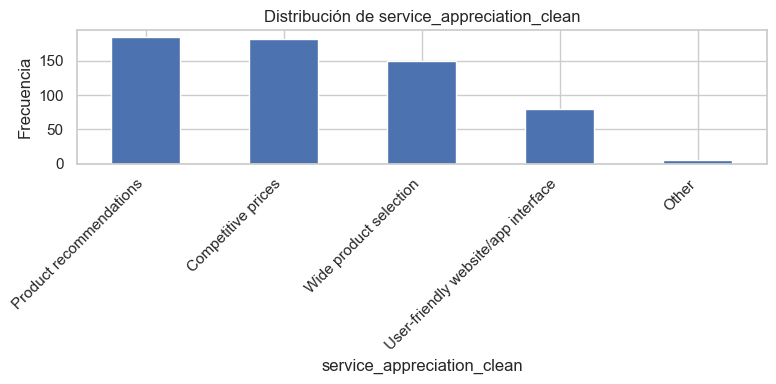


=== improvement_areas_clean ===


,count,percent
improvement_areas_clean,,
Customer service responsiveness,216,36.00
Product quality and accuracy,159,26.50
Reducing packaging waste,133,22.17
Shipping speed and reliability,78,13.00
Other,14,2.33


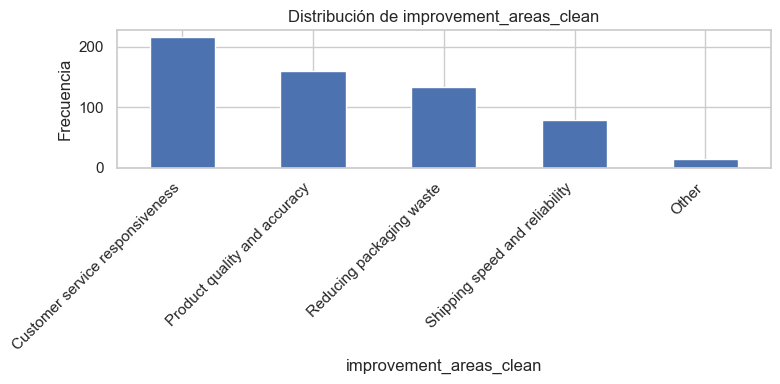


=== personalized_recommendation_frequency ===


,count,percent
personalized_recommendation_frequency,,
No,250,41.67
Sometimes,228,38.00
Yes,122,20.33


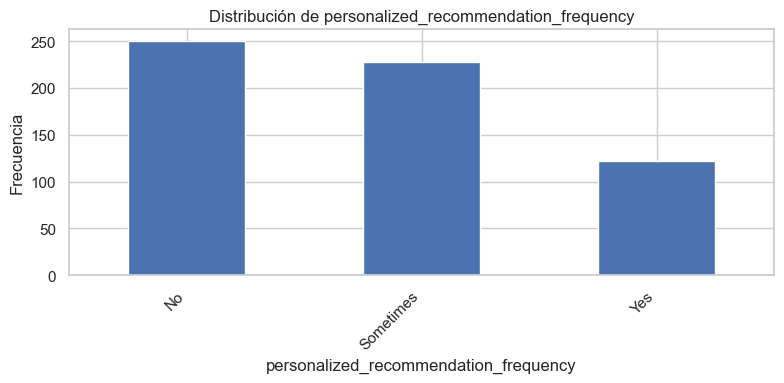


=== edad_grupo ===


,count,percent
edad_grupo,,
menos_60,592,98.67
60_o_mas,8,1.33


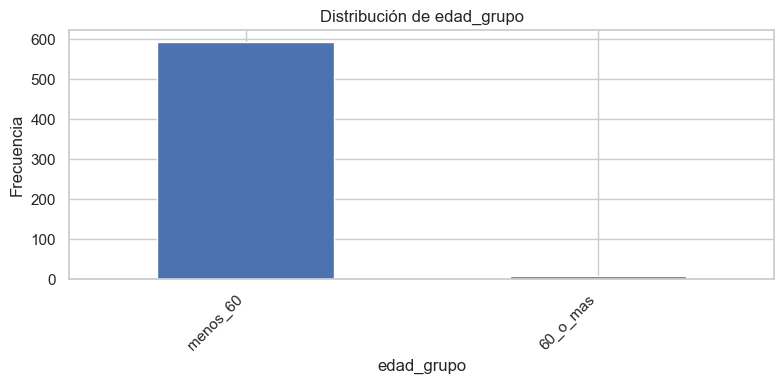

In [64]:
cat_target_cols = [
    "gender",
    "purchase_frequency",
    "browsing_frequency",
    "product_search_method",
    "search_result_exploration",
    "cart_completion_frequency",
    "saveforlater_frequency",
    "review_reliability",
    "review_helpfulness",
    "service_appreciation_clean",
    "improvement_areas_clean",
    "personalized_recommendation_frequency",
    "edad_grupo",
]

cat_target_cols = [c for c in cat_target_cols if c in df_eda.columns]

for col in cat_target_cols:
    categorical_univariate_report(df_eda, col, topn=10)

### 14. Revisión final y guardado del dataset preparado

Por último, reviso las nuevas variables creadas y guardo un dataset
preparado para usar en los análisis bivariantes posteriores.

In [65]:
new_cols = [
    "buys_beauty",
    "buys_fashion",
    "buys_groceries",
    "buys_home",
    "buys_others",
    "purchase_frequency_ord",
    "browsing_frequency_ord",
    "cart_completion_frequency_ord",
    "saveforlater_frequency_ord",
    "review_reliability_ord",
    "review_helpfulness_ord",
    "recommendation_helpfulness_ord",
    "search_result_exploration_ord",
    "personalized_recommendation_frequency_ord",
    "age_outlier_60",
    "edad_grupo",
    "service_appreciation_clean",
    "improvement_areas_clean",
]

new_cols = [c for c in new_cols if c in df_eda.columns]

print("Nuevas columnas creadas:")
print(new_cols)
display(df_eda[new_cols].head())

df_eda.to_csv("../data/amazon_customer_behavior_prepared.csv", index=False)

print("\nArchivo guardado: amazon_customer_behavior_prepared.csv")
print("Dimensión final del dataset preparado:", df_eda.shape)

Nuevas columnas creadas:
['buys_beauty', 'buys_fashion', 'buys_groceries', 'buys_home', 'buys_others', 'purchase_frequency_ord', 'browsing_frequency_ord', 'cart_completion_frequency_ord', 'saveforlater_frequency_ord', 'review_reliability_ord', 'review_helpfulness_ord', 'recommendation_helpfulness_ord', 'search_result_exploration_ord', 'personalized_recommendation_frequency_ord', 'age_outlier_60', 'edad_grupo', 'service_appreciation_clean', 'improvement_areas_clean']


,buys_beauty,buys_fashion,buys_groceries,buys_home,buys_others,purchase_frequency_ord,browsing_frequency_ord,cart_completion_frequency_ord,saveforlater_frequency_ord,review_reliability_ord,review_helpfulness_ord,recommendation_helpfulness_ord,search_result_exploration_ord,personalized_recommendation_frequency_ord,age_outlier_60,edad_grupo,service_appreciation_clean,improvement_areas_clean
0,True,False,False,False,False,2,2,2,2,2,2,2,1,2,0,menos_60,Competitive prices,Reducing packaging waste
1,False,True,False,False,False,1,1,3,1,4,2,1,1,2,0,menos_60,Wide product selection,Reducing packaging waste
2,False,True,True,False,False,2,1,2,1,2,0,0,1,0,0,menos_60,Competitive prices,Product quality and accuracy
3,True,True,False,False,True,1,1,2,2,4,2,1,0,1,0,menos_60,Competitive prices,Product quality and accuracy
4,True,True,False,False,False,0,1,2,1,4,2,2,1,2,0,menos_60,Competitive prices,Product quality and accuracy



Archivo guardado: amazon_customer_behavior_prepared.csv
Dimensión final del dataset preparado: (600, 42)


### 15. Bivariante – Edad vs importancia y fiabilidad de reseñas

##### Hipótesis: “A mayor edad, más dependen de las reseñas”.

In [89]:
# Crear tramos de edad más detallados
df_eda["tramo_edad"] = pd.cut(
    df_eda["age"],
    bins=[0, 25, 35, 50, 60, 120],
    labels=["<=25", "26-35", "36-50", "51-60", "60+"],
    right=True,
    include_lowest=True
)

# Ver cómo quedan los tramos
df_eda["tramo_edad"].value_counts()

tramo_edad
<=25     274
26-35    168
36-50    129
51-60     24
60+        5
Name: count, dtype: int64

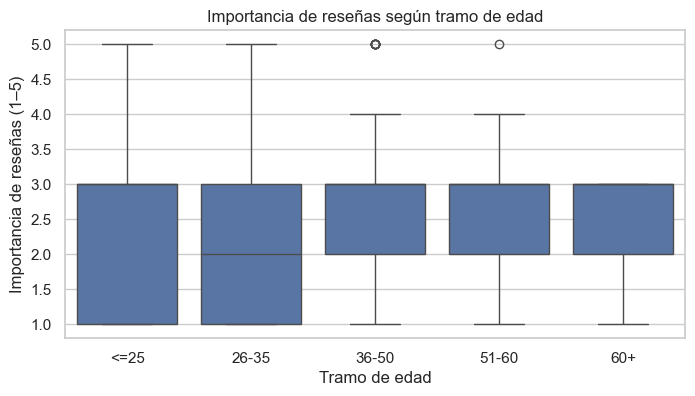

,mean,count,std
tramo_edad,,,
<=25,2.416058,274,1.235271
26-35,2.500000,168,1.208751
36-50,2.527132,129,1.090280
51-60,2.875000,24,0.946963
60+,2.400000,5,0.894427


In [95]:
# Boxplot: importancia de reseñas por tramo de edad
sns.boxplot(data=df_eda, x="tramo_edad", y="customer_reviews_importance")
plt.title("Importancia de reseñas según tramo de edad")
plt.xlabel("Tramo de edad")
plt.ylabel("Importancia de reseñas (1–5)")
plt.show()

# Agrupado: media de importancia de reseñas por tramo de edad
df_eda.groupby("tramo_edad")["customer_reviews_importance"].agg(["mean", "count", "std"])

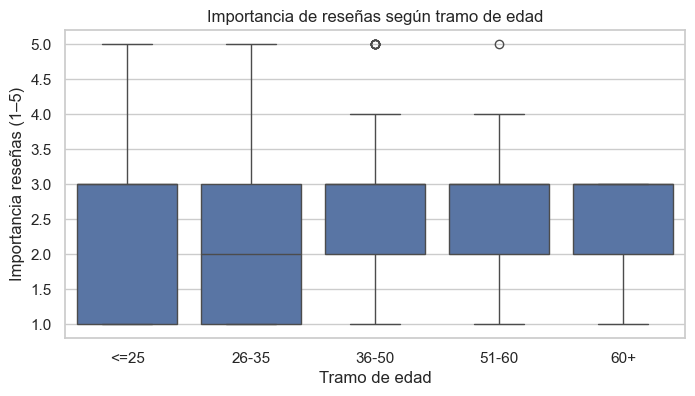

ANOVA tramo_edad → F=0.933, p=0.4441
Pearson edad vs importancia reseñas: r=0.082, p=0.0458


In [96]:
# ANOVA: importancia de reseñas según tramo de edad
df_eda.groupby("tramo_edad")["customer_reviews_importance"].agg(["mean", "count", "std"])

sns.boxplot(data=df_eda, x="tramo_edad", y="customer_reviews_importance")
plt.title("Importancia de reseñas según tramo de edad")
plt.xlabel("Tramo de edad")
plt.ylabel("Importancia reseñas (1–5)")
plt.show()

# ANOVA
samples = [
    df_eda.loc[df_eda["tramo_edad"] == g, "customer_reviews_importance"].dropna()
    for g in df_eda["tramo_edad"].dropna().unique()
]
f_stat, p_val = stats.f_oneway(*samples)
print(f"ANOVA tramo_edad → F={f_stat:.3f}, p={p_val:.4f}")

# Pearson edad vs importancia de reseñas
r_age_reviews, p_age_reviews = stats.pearsonr(
    df_eda["age"],
    df_eda["customer_reviews_importance"]
)
print(f"Pearson edad vs importancia reseñas: r={r_age_reviews:.3f}, p={p_age_reviews:.4f}")

### Se observa un aumento progresivo en la importancia asignada a las reseñas de clientes a medida que aumenta la edad, especialmente en el grupo de 51–60 años. El grupo 60+ es demasiado pequeño para extraer conclusiones robustas.

### 16. Bivariante – Frecuencia de navegación vs finalización de carrito
#### hipótesis “usuarios que navegan más → más probabilidad de completar compra” 

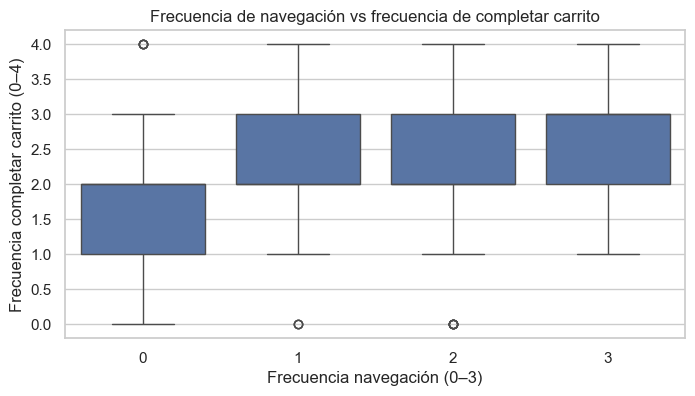

cart_completion_frequency_ord                  \
                                                mean count       std   
browsing_frequency_ord                                                 
0                                           1.701299    77  1.076849   
1                                           2.170854   199  0.766044   
2                                           2.286290   248  0.845740   
3                                           2.710526    76  0.780013   

                       shopping_satisfaction                  
                                        mean count       std  
browsing_frequency_ord                                        
0                                   2.714286    77  1.212405  
1                                   2.527638   199  0.914524  
2                                   2.439516   248  0.971440  
3                                   2.118421    76  1.095045

In [92]:
# Boxplot: frecuencia de completar carrito según frecuencia de navegación
sns.boxplot(
    data=df_eda,
    x="browsing_frequency_ord",
    y="cart_completion_frequency_ord"
)
plt.title("Frecuencia de navegación vs frecuencia de completar carrito")
plt.xlabel("Frecuencia navegación (0–3)")
plt.ylabel("Frecuencia completar carrito (0–4)")
plt.show()

# Agrupado: medias por nivel de navegación
df_eda.groupby("browsing_frequency_ord")[
    ["cart_completion_frequency_ord", "shopping_satisfaction"]
].agg(["mean", "count", "std"])

### 17. Bivariante – Dejar reseñas vs satisfacción

### 18. Bivariante – Factores de abandono vs frecuencia de completar carrito

##### ¿por qué abandonan el carrito?


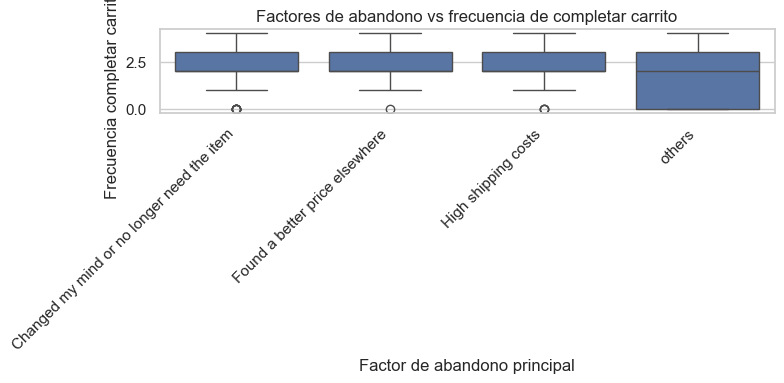

,mean,count
cart_abandonment_factors,,
Changed my mind or no longer need the item,2.420833,240
Found a better price elsewhere,2.397638,254
High shipping costs,2.528571,70
others,3.083333,36


In [72]:
# Boxplot: frecuencia de completar carrito según factor de abandono
sns.boxplot(
    data=df_eda,
    x="cart_abandonment_factors",
    y="cart_completion_frequency_ord"
)
plt.title("Factores de abandono vs frecuencia de completar carrito")
plt.xlabel("Factor de abandono principal")
plt.ylabel("Frecuencia completar carrito (0–4)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Tabla: media de shopping_satisfaction por factor de abandono
df_eda.groupby("cart_abandonment_factors")["shopping_satisfaction"].agg(["mean", "count"])

### 19. Bivariante – Segmentos según frecuencia de compra y navegación
##### tipos de compradores según comportamiento

* purchase_frequency_ord

* con browsing_frequency_ord

* y ver cómo se reparte shopping_satisfaction y service_appreciation_clean.

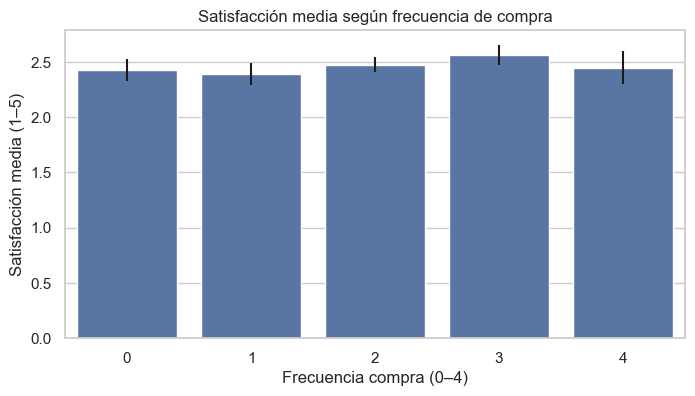

In [74]:
summary_freq_sat = (
    df_eda
    .groupby("purchase_frequency_ord")["shopping_satisfaction"]
    .agg(["mean", "count", "std"])
    .reset_index()
)

sns.barplot(
    data=summary_freq_sat,
    x="purchase_frequency_ord",
    y="mean",
    yerr=summary_freq_sat["std"] / np.sqrt(summary_freq_sat["count"]),
    color="#4C72B0",
)
plt.title("Satisfacción media según frecuencia de compra")
plt.xlabel("Frecuencia compra (0–4)")
plt.ylabel("Satisfacción media (1–5)")
plt.show()


### 20. Funciones auxiliares para análisis bivariante

In [84]:
def pearson_corr(x, y):
    """
    Correlación de Pearson entre dos variables numéricas.
    Devuelve coeficiente r y valor p.
    """
    # Eliminar filas con NaN en cualquiera de las dos
    df_tmp = df_eda[[x, y]].dropna()
    r, p = stats.pearsonr(df_tmp[x], df_tmp[y])
    print(f"Correlación de Pearson entre {x} y {y}: r = {r:.3f}, p = {p:.4f}")
    return r, p


def chi_square_test(cat1, cat2):
    """
    Test chi-cuadrado de independencia entre dos variables categóricas.
    """
    tabla = pd.crosstab(df_eda[cat1], df_eda[cat2])
    chi2, p, dof, expected = stats.chi2_contingency(tabla)
    print(f"Chi-cuadrado entre {cat1} y {cat2}: chi2 = {chi2:.3f}, gl = {dof}, p = {p:.4f}")
    return tabla, chi2, p, dof, expected


def t_or_mannwhitney(num_col, bin_col):
    """
    Comparación de medias de una variable numérica entre dos grupos
    definidos por una variable binaria (0/1 o 2 categorías).
    
    1) Comprueba normalidad aproximada (Shapiro) en cada grupo.
    2) Si ambas son ~normales y tamaños razonables → t de Student.
    3) Si no → Mann-Whitney U.
    """
    df_tmp = df_eda[[num_col, bin_col]].dropna()
    grupos = df_tmp[bin_col].unique()
    if len(grupos) != 2:
        raise ValueError(f"{bin_col} no tiene exactamente 2 categorías")

    g1, g2 = grupos
    x1 = df_tmp[df_tmp[bin_col] == g1][num_col]
    x2 = df_tmp[df_tmp[bin_col] == g2][num_col]

    # Normalidad (Shapiro-Wilk) – ojo, muy sensible; aquí solo orientativa
    stat1, p1 = stats.shapiro(x1)
    stat2, p2 = stats.shapiro(x2)
    print(f"Normalidad {bin_col}={g1}: p={p1:.4f} | {bin_col}={g2}: p={p2:.4f}")

    if p1 > 0.05 and p2 > 0.05:
        # t-test para muestras independientes
        t_stat, p_val = stats.ttest_ind(x1, x2, equal_var=False)
        print(f"t-test para {num_col} por {bin_col}: t={t_stat:.3f}, p={p_val:.4f}")
        metodo = "t-test"
    else:
        # Mann-Whitney U
        u_stat, p_val = stats.mannwhitneyu(x1, x2, alternative="two-sided")
        print(f"Mann-Whitney para {num_col} por {bin_col}: U={u_stat:.3f}, p={p_val:.4f}")
        metodo = "Mann-Whitney"

    return metodo, p_val


def anova_oneway(num_col, cat_col):
    """
    ANOVA de un factor para num_col según niveles de cat_col (>=3 grupos).
    Si los supuestos no se cumplen, da pie a usar Kruskal-Wallis.
    """
    df_tmp = df_eda[[num_col, cat_col]].dropna()
    grupos = df_tmp[cat_col].unique()

    if len(grupos) < 3:
        raise ValueError(f"{cat_col} tiene menos de 3 niveles; mejor usar t-test/Mann-Whitney")

    samples = [df_tmp[df_tmp[cat_col] == g][num_col] for g in grupos]

    f_stat, p_val = stats.f_oneway(*samples)
    print(f"ANOVA para {num_col} por {cat_col}: F={f_stat:.3f}, p={p_val:.4f}")
    return f_stat, p_val

### 21. Numérica vs numérica – Correlaciones de Pearson

Correlación de Pearson entre browsing_frequency_ord y cart_completion_frequency_ord: r = 0.279, p = 0.0000


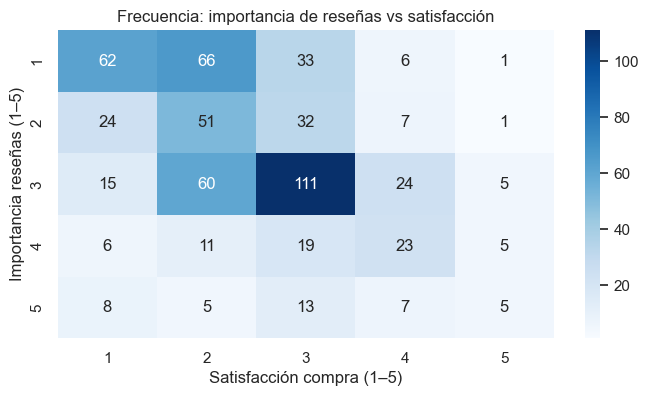

Correlación de Pearson entre customer_reviews_importance y shopping_satisfaction: r = 0.402, p = 0.0000


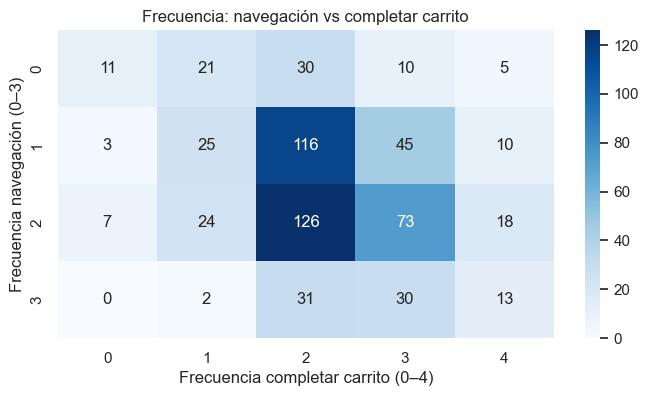

In [86]:
# 20.1 Frecuencia de navegación vs frecuencia de completar carrito
pearson_corr("browsing_frequency_ord", "cart_completion_frequency_ord")

# Tabla de frecuencias cruzadas
tabla_reviews_sat = pd.crosstab(
    df_eda["customer_reviews_importance"],
    df_eda["shopping_satisfaction"]
)

sns.heatmap(
    tabla_reviews_sat,
    annot=True, fmt="d",
    cmap="Blues"
)
plt.title("Frecuencia: importancia de reseñas vs satisfacción")
plt.xlabel("Satisfacción compra (1–5)")
plt.ylabel("Importancia reseñas (1–5)")
plt.show()

# 23.2 Importancia de reseñas vs satisfacción de compra
pearson_corr("customer_reviews_importance", "shopping_satisfaction")

tabla_browse_cart = pd.crosstab(
    df_eda["browsing_frequency_ord"],
    df_eda["cart_completion_frequency_ord"]
)

sns.heatmap(
    tabla_browse_cart,
    annot=True, fmt="d",
    cmap="Blues"
)
plt.title("Frecuencia: navegación vs completar carrito")
plt.xlabel("Frecuencia completar carrito (0–4)")
plt.ylabel("Frecuencia navegación (0–3)")
plt.show()

##### Existe una correlación positiva moderada entre la importancia que los usuarios asignan a las reseñas y su satisfacción global con la experiencia de compra (r ≈ 0.40, p < 0.001). Esto indica que quienes consideran más relevantes las reseñas tienden a reportar una mayor satisfacción.

##### La frecuencia de navegación está débil–moderadamente asociada a la frecuencia con la que los usuarios completan el carrito (r ≈ 0.28, p < 0.001), lo que sugiere que un mayor uso de la plataforma se acompaña de una probabilidad ligeramente superior de finalizar la compra, aunque la relación no es especialmente fuerte

### 22. Categórica vs categórica – tablas de contingencia y chi-cuadrado

In [94]:
# Variable binaria: alta frecuencia de completar carrito (>=3)
df_eda["high_cart_completion"] = (df_eda["cart_completion_frequency_ord"] >= 3).astype(int)

# 24.1 Edad (grupo) vs alta finalización de carrito
tabla_age_cart, chi2, p, dof, expected = chi_square_test("edad_grupo", "high_cart_completion")
display(tabla_age_cart)
print(f"p-value = {p:.4f}")

# 24.2 Aspectos del servicio apreciados vs áreas de mejora
tabla_serv_imp, chi2, p, dof, expected = chi_square_test(
    "service_appreciation_clean",
    "improvement_areas_clean"
)
display(tabla_serv_imp)
print(f"p-value = {p:.4f}")

Chi-cuadrado entre edad_grupo y high_cart_completion: chi2 = 0.027, gl = 1, p = 0.8687


high_cart_completion,0,1
edad_grupo,,
60_o_mas,6,2
menos_60,390,202


p-value = 0.8687
Chi-cuadrado entre service_appreciation_clean y improvement_areas_clean: chi2 = 139.855, gl = 16, p = 0.0000


improvement_areas_clean,Customer service responsiveness,Other,Product quality and accuracy,Reducing packaging waste,Shipping speed and reliability
service_appreciation_clean,,,,,
Competitive prices,78,5,36,41,22
Other,0,2,0,3,0
Product recommendations,81,0,30,63,11
User-friendly website/app interface,14,1,27,13,24
Wide product selection,43,6,66,13,21


p-value = 0.0000



#### Dejar reseñas y experiencia de compra

low_satisfaction,0,1
review_left_bin,,
0,48,242
1,36,274


Chi-cuadrado review_left vs low_satisfaction: chi2=2.639, p=0.1043
Normalidad review_left_bin=1: p=0.0000 | review_left_bin=0: p=0.0000
Mann-Whitney para shopping_satisfaction por review_left_bin: U=43560.500, p=0.4941
Método: Mann-Whitney, p=0.4941


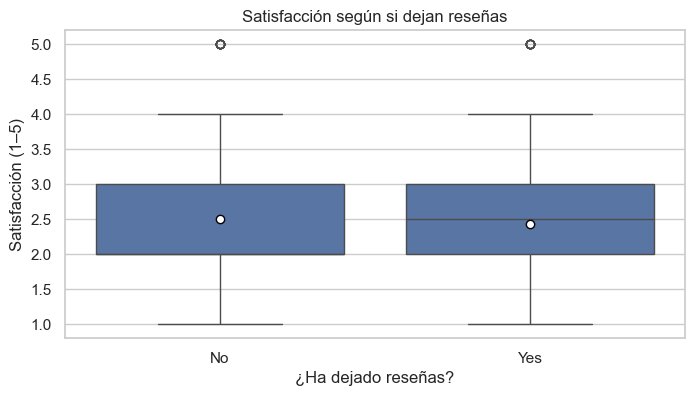

In [98]:
# Binarias: dejó reseña y baja satisfacción (<=3)
df_eda["review_left_bin"] = df_eda["review_left"].astype(str).str.lower().map(
    {"yes": 1, "no": 0}
)
df_eda["low_satisfaction"] = (df_eda["shopping_satisfaction"] <= 3).astype(int)

# 1.1 Tabla de contingencia y chi-cuadrado
tabla_review_sat = pd.crosstab(df_eda["review_left_bin"], df_eda["low_satisfaction"])
display(tabla_review_sat)

chi2, p_chi, dof, expected = stats.chi2_contingency(tabla_review_sat)
print(f"Chi-cuadrado review_left vs low_satisfaction: chi2={chi2:.3f}, p={p_chi:.4f}")

# 1.2 Comparar satisfacción numérica entre quienes dejan/no dejan reseña
metodo_review, p_review = t_or_mannwhitney("shopping_satisfaction", "review_left_bin")
print(f"Método: {metodo_review}, p={p_review:.4f}")

sns.boxplot(data=df_eda, x="review_left", y="shopping_satisfaction", showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.title("Satisfacción según si dejan reseñas")
plt.xlabel("¿Ha dejado reseñas?")
plt.ylabel("Satisfacción (1–5)")
plt.show()

#### Por qué se abandona el carrito?

Distribución de factores de abandono del carrito (%):


cart_abandonment_factors
Found a better price elsewhere                42.3
Changed my mind or no longer need the item    40.0
High shipping costs                           11.7
others                                         6.0
Name: proportion, dtype: float64


Satisfacción media por factor de abandono:


,mean,count,std
cart_abandonment_factors,,,
Changed my mind or no longer need the item,2.42,240,0.97
Found a better price elsewhere,2.40,254,1.01
High shipping costs,2.53,70,1.03
others,3.08,36,1.13


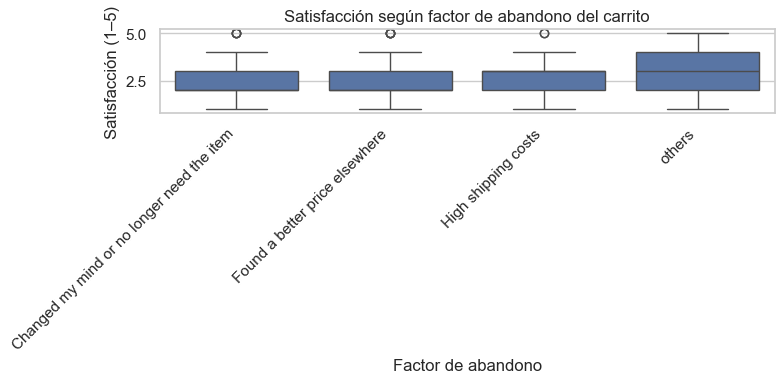

In [99]:
# 2.1 Frecuencias de factores de abandono (en %)
freq_abandono = (
    df_eda["cart_abandonment_factors"]
    .value_counts(normalize=True)
    .round(3) * 100
)
print("Distribución de factores de abandono del carrito (%):")
display(freq_abandono)

# 2.2 Satisfacción media según factor de abandono
res_abandono_sat = df_eda.groupby("cart_abandonment_factors")[
    "shopping_satisfaction"
].agg(["mean", "count", "std"]).round(2)
print("\nSatisfacción media por factor de abandono:")
display(res_abandono_sat)

sns.boxplot(
    data=df_eda,
    x="cart_abandonment_factors",
    y="shopping_satisfaction"
)
plt.title("Satisfacción según factor de abandono del carrito")
plt.xlabel("Factor de abandono")
plt.ylabel("Satisfacción (1–5)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [100]:
(df_eda["cart_abandonment_factors"]
 .value_counts(normalize=True)
 .round(3) * 100)

cart_abandonment_factors
Found a better price elsewhere                42.3
Changed my mind or no longer need the item    40.0
High shipping costs                           11.7
others                                         6.0
Name: proportion, dtype: float64

######## Peso relativo de edad, uso y reseñas en la satisfacción

In [101]:
vars_corr = [
    "shopping_satisfaction",
    "age",
    "browsing_frequency_ord",
    "customer_reviews_importance",
    "review_reliability_ord",
]

corr = df_eda[vars_corr].corr()

# Ordenar por correlación con la satisfacción
corr_with_sat = corr["shopping_satisfaction"].sort_values(ascending=False)
print("Correlaciones con la satisfacción de compra:")
display(corr_with_sat)

Correlaciones con la satisfacción de compra:


shopping_satisfaction          1.000000
customer_reviews_importance    0.401729
age                            0.006013
browsing_frequency_ord        -0.146761
review_reliability_ord        -0.254949
Name: shopping_satisfaction, dtype: float64